# 03 — Modèles Prédictifs

Projections ARIMA et Prophet sur les effectifs retraités et les montants de pension.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.models import forecast_arima, forecast_prophet, fit_linear, evaluate
from src.visualize import plot_forecast, save_fig
%matplotlib inline

## 1. ARIMA — Projection des effectifs retraités (horizon 10 ans)

In [2]:
df_genre = pd.read_parquet('../data/processed/nombre-de-retraites-au-31-decembre-par-genre.parquet')
serie_total = (df_genre.groupby('annees_transfo')['nombre_de_retraites']
               .sum().sort_index().astype(float))

print(f'Série : {serie_total.index[0]} → {serie_total.index[-1]} ({len(serie_total)} points)')
print(f'Dernier effectif connu : {serie_total.iloc[-1]:,.0f}')

Série : 1974 → 2025 (52 points)
Dernier effectif connu : 15,567,450


D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is av

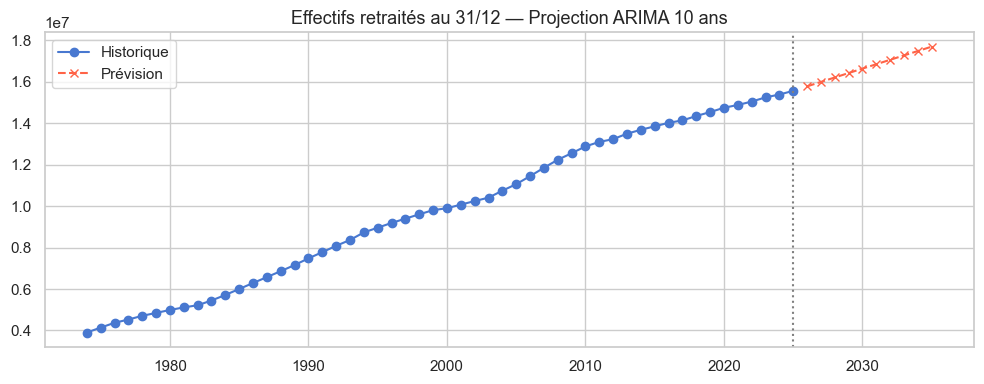


Projection ARIMA :
2026    15782866.0
2027    15997828.0
2028    16212338.0
2029    16426397.0
2030    16640005.0
2031    16853163.0
2032    17065873.0
2033    17278136.0
2034    17489952.0
2035    17701322.0


In [3]:
forecast_arima_eff = forecast_arima(serie_total, steps=10)
fig = plot_forecast(serie_total, forecast_arima_eff,
                    title='Effectifs retraités au 31/12 — Projection ARIMA 10 ans')
save_fig(fig, 'forecast_arima_effectifs')
plt.show()
print('\nProjection ARIMA :')
print(forecast_arima_eff.round(0).to_string())

## 2. Prophet — Projection des effectifs (avec détection de ruptures)

11:04:51 - cmdstanpy - INFO - Chain [1] start processing


11:04:51 - cmdstanpy - INFO - Chain [1] done processing


D:\DEV\retraites-opendata\.venv\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


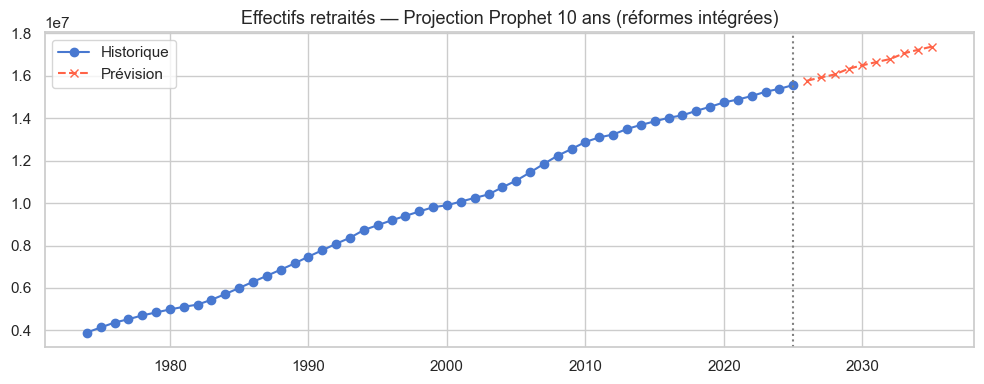

In [4]:
PERIODS = 10
# Reformatage pour Prophet : colonnes 'ds' (date) et 'y' (valeur)
df_prophet = pd.DataFrame({
    'ds': pd.to_datetime(serie_total.index.astype(str) + '-01-01'),
    'y': serie_total.values
})

# Dates des réformes majeures comme changepoints
changepoints = [
    '1983-01-01',  # retraite à 60 ans (Loi Auroux)
    '1993-01-01',  # réforme Balladur (durée cotisation)
    '2003-01-01',  # réforme Fillon
    '2010-01-01',  # report âge légal à 62 ans
    '2023-01-01',  # réforme retraite à 64 ans
]

forecast_prophet_df = forecast_prophet(df_prophet, periods=PERIODS, changepoints=changepoints)

# Les PERIODS dernières lignes du DataFrame Prophet = les futures prédictions
last_year = serie_total.index[-1]
future_rows = forecast_prophet_df.tail(PERIODS)
future_index = [last_year + i for i in range(1, len(future_rows) + 1)]
serie_forecast_prophet = pd.Series(future_rows['yhat'].values, index=future_index)

fig = plot_forecast(serie_total, serie_forecast_prophet,
                    title='Effectifs retraités — Projection Prophet 10 ans (réformes intégrées)')
save_fig(fig, 'forecast_prophet_effectifs')
plt.show()

## 3. ARIMA — Projection du montant mensuel moyen de pension

D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is av

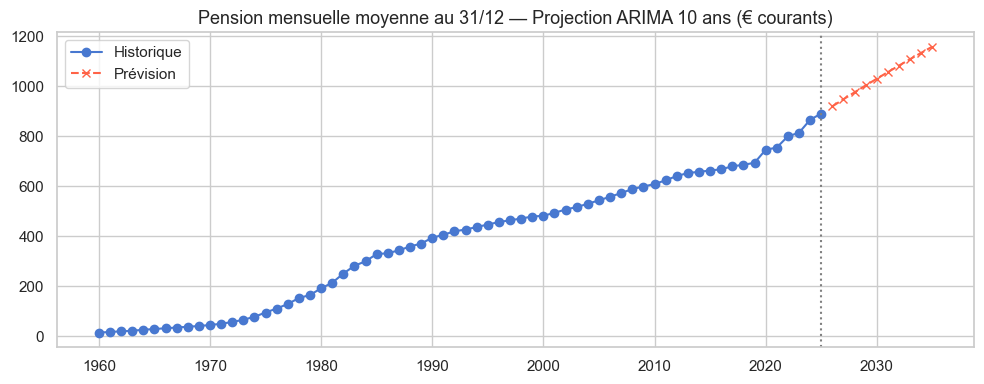


Projection ARIMA montant (€/mois) :
2026     920.0
2027     948.0
2028     976.0
2029    1003.0
2030    1030.0
2031    1057.0
2032    1083.0
2033    1109.0
2034    1134.0
2035    1159.0


In [5]:
df_montant = pd.read_parquet('../data/processed/montant-global-de-la-retraite-au-31-decembre.parquet')
df_montant = df_montant.dropna(subset=['annees_normees']).sort_values('annees_normees')
serie_montant = df_montant.set_index('annees_normees')[
    'montant_mensuel_moyen_au_31_decembre_de_la_retraite_globale_en_euros'
].astype(float)

forecast_montant = forecast_arima(serie_montant, steps=10)
fig = plot_forecast(serie_montant, forecast_montant,
                    title='Pension mensuelle moyenne au 31/12 — Projection ARIMA 10 ans (€ courants)')
save_fig(fig, 'forecast_arima_montant')
plt.show()
print('\nProjection ARIMA montant (€/mois) :')
print(forecast_montant.round(0).to_string())

## 4. Régression linéaire — Montant nominal vs montant corrigé inflation

Coef : 1.2681  |  Intercept : -428.83
MAE  : 84.5 €  |  RMSE : 102.8 €


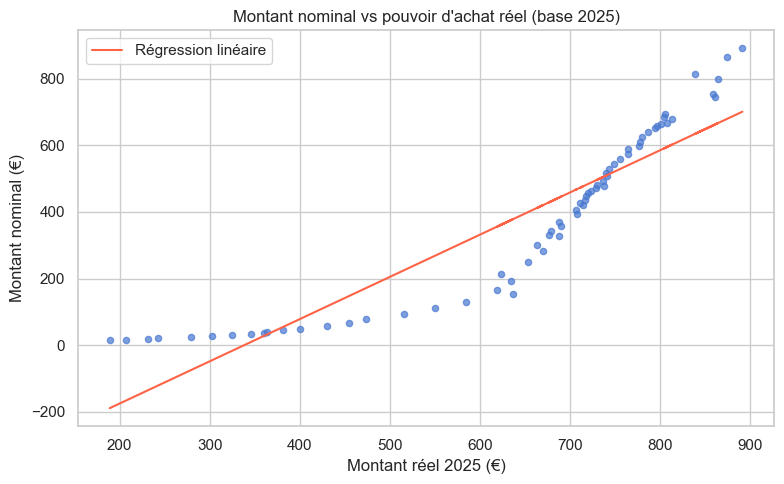

In [6]:
col_nominal = 'montant_mensuel_moyen_au_31_decembre_de_la_retraite_globale_en_euros'
col_2025    = 'montant_equivalent_en_2025_montant_en_euros_corrige_de_l_inflation'

df_reg = df_montant.dropna(subset=[col_nominal, col_2025])
x = df_reg[col_2025]  # pouvoir d'achat réel
y = df_reg[col_nominal]  # valeur nominale

model, mae, rmse = fit_linear(x, y)
print(f'Coef : {model.coef_[0]:.4f}  |  Intercept : {model.intercept_:.2f}')
print(f'MAE  : {mae:.1f} €  |  RMSE : {rmse:.1f} €')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=20, alpha=0.7)
ax.plot(x, model.predict(x.values.reshape(-1,1)), color='tomato', label='Régression linéaire')
ax.set_xlabel('Montant réel 2025 (€)')
ax.set_ylabel('Montant nominal (€)')
ax.set_title('Montant nominal vs pouvoir d\'achat réel (base 2025)', fontsize=12)
ax.legend()
plt.tight_layout()
save_fig(fig, 'regression_nominal_reel')
plt.show()

## 5. Comparaison ARIMA vs Prophet — Métriques

In [7]:
# Évaluation in-sample : entraîner sur 80%, tester sur 20%
n = len(serie_total)
split = int(n * 0.8)
train, test = serie_total.iloc[:split], serie_total.iloc[split:]

fc_arima_test = forecast_arima(train, steps=len(test))
mae_a, rmse_a = evaluate(test, fc_arima_test)

df_train_prophet = pd.DataFrame({
    'ds': pd.to_datetime(train.index.astype(str) + '-01-01'),
    'y': train.values
})
fc_prophet_test_df = forecast_prophet(df_train_prophet, periods=len(test))
fc_prophet_vals = fc_prophet_test_df.tail(len(test))['yhat'].values
fc_prophet_test = pd.Series(fc_prophet_vals, index=test.index)
mae_p, rmse_p = evaluate(test, fc_prophet_test)

print('Comparaison modèles (effectifs, hors-échantillon 20%) :')
print(f'  ARIMA  — MAE : {mae_a:,.0f}  |  RMSE : {rmse_a:,.0f}')
print(f'  Prophet — MAE : {mae_p:,.0f}  |  RMSE : {rmse_p:,.0f}')

D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

11:04:52 - cmdstanpy - INFO - Chain [1] start processing


11:04:52 - cmdstanpy - INFO - Chain [1] done processing


Comparaison modèles (effectifs, hors-échantillon 20%) :
  ARIMA  — MAE : 442,289  |  RMSE : 495,947
  Prophet — MAE : 1,052,275  |  RMSE : 1,129,732


D:\DEV\retraites-opendata\.venv\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
